In [188]:
# Import packages
import os
import pandas as pd
from newspaper import Article
import spacy
import re
from gensim.models import Phrases
from tqdm.auto import tqdm
import pdb
import tomotopy as tp
import spacy
import stanza
from langdetect import detect, LangDetectException
import numpy as np

### **Read files**

In [189]:
# 1. Load your downloaded CSV file
# IMPORTANT: Change 'your_downloaded_file.csv' to the actual name of your file!
file_name = "../data/gdelt/April16th_w_ELECTION_PROPAGANDA.csv"
print(f"Loading data from {file_name}...\n")
df = pd.read_csv(file_name)

# CLEANING THE DATA: remove duplicate rows
rows_before = len(df)
print(f"Number of rows before removing duplicates: {rows_before}")

df.drop_duplicates(inplace=True)

rows_after = len(df)
print(f"Number of rows after removing duplicates: {rows_after}")


Loading data from ../data/gdelt/April16th_w_ELECTION_PROPAGANDA.csv...

Number of rows before removing duplicates: 2943
Number of rows after removing duplicates: 2281


### **Webscrapping**

In [190]:
print("\n" + "=" * 50)
print(" Date extraction and context retrieval from news articles")
print("=" * 50)

# --- Controls ---
N = len(df)  # Set to a smaller number for testing, or keep as is to process all
random_state = 42
cache_file = "../gdelt/articles_with_texts.csv"
use_cached_df = True   # If True and file exists, load it instead of scraping
save_cache = True      # Save freshly scraped data for next runs

if use_cached_df and os.path.exists(cache_file):
    print(f"Loading cached dataframe from: {cache_file}")
    df_w_texts = pd.read_csv(cache_file)
    print(f"Loaded {len(df_w_texts)} rows from cache.")
else:
    print("No cache found (or caching disabled). Starting scraping...")

    available_urls = df['News_URL'].dropna().unique().tolist()
    sample_n = min(N, len(available_urls))
    urls = pd.Series(available_urls).sample(n=sample_n, random_state=random_state, replace = False).tolist()

    rows = []

    for url in tqdm(urls, desc="Scraping articles", unit="article"):
        try:
            article = Article(url)
            article.download()
            article.parse()
            text = article.text

            event_date = df.loc[df['News_URL'] == url, 'Event_Date'].iloc[0]
            rows.append({
                'Event_Date': event_date,
                'News_URL': url,
                'Full_Text': text
            })

        except Exception:
            # Keep running even if one URL fails
            continue

    df_w_texts = pd.DataFrame(rows, columns=['Event_Date', 'News_URL', 'Full_Text'])
    print(f"Scraped {len(df_w_texts)} articles successfully.")

    if save_cache:
        df_w_texts.to_csv(cache_file, index=False)
        print(f"Saved cache to: {cache_file}")


 Date extraction and context retrieval from news articles
Loading cached dataframe from: ../gdelt/articles_with_texts.csv
Loaded 1129 rows from cache.


In [191]:
df_w_texts["Full_Text"].iloc[0]

'The House yesterday [Macau time] passed a bill that would lead to a nationwide ban of the popular video app TikTok if its China-based owner doesn’t sell its stake, as lawmakers acted on concerns that the company’s current ownership structure is a national security threat.\n\nThe bill, passed by a vote of 352-65, now goes to the Senate, where its prospects are unclear.\n\nTikTok, which has more than 170 million American users, is a wholly-owned subsidiary of Chinese technology firm ByteDance Ltd.\n\nThe lawmakers contend that ByteDance “is beholden to the Chinese government,” which could demand access to the data of TikTok’s consumers in the U.S. whenever it wants. The worry stems from a set of Chinese national security laws that compel organizations to assist with intelligence gathering.\n\n“We have given TikTok a clear choice,” said Rep. Cathy McMorris Rodgers, R-Wash. “Separate from your parent company ByteDance, which is beholden to the CCP, and remain operational in the United Sta

In [192]:
def clean_scraped_text(text):
    # \s+ looks for ANY whitespace (\n, \t, \r, or multiple spaces) 
    # and replaces it with a single standard space ' '
    text = re.sub(r'-\s+', '', text)
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'\[.*?\]', '', text)

    # 2. Remove URLs (starts with http or www)
    text = re.sub(r'http\S+|www\.\S+', '', text)
    
    # 3. Remove email addresses (just in case)
    text = re.sub(r'\S+@\S+', '', text)
    
    # 4. Remove standalone equals signs or weird artifacts 
    # (Sometimes URLs leave behind an '=' if the regex misses a query string)
    text = text.replace('=', ' ')
    
    # .strip() removes any lingering spaces at the very beginning or end of the article
    return text.strip()

In [193]:
df_w_texts.dropna(inplace=True)
df_w_texts.reset_index(drop=True, inplace=True)

for i in range(len(df_w_texts)):
    df_w_texts.loc[i, 'Full_Text'] = clean_scraped_text(df_w_texts.loc[i, 'Full_Text'])

df_w_texts.drop(df_w_texts[df_w_texts['Full_Text'] == ''].index, inplace=True)


In [194]:
df_w_texts["Full_Text"].iloc[1]

"As the US presidential election draws nearer, Iran has intensified its efforts to sway American public opinion, joining the ongoing influence campaigns by Russia and China. According to a new report from Microsoft's Threat Analysis Center, Iranian operatives are using fake news sites and cyber operations to target voters across the political spectrum. This move marks a significant escalation in Iran's attempts to influence the U.S. election, with researchers warning that these activities could increase as voting day approaches. Fake news sites target both political left and right Microsoft's report highlights several fake news sites attributed to Iranian operations, designed to appeal to both liberal and conservative audiences. One of these sites, Nio Thinker, positions itself as a progressive news outlet, publishing content critical of former President Donald Trump while praising Vice President Kamala Harris. Another site, Savannah Time, takes on a conservative voice, blending local 

In [195]:
df_w_texts.sample(5)

,Event_Date,News_URL,Full_Text
891,20240205,https://www.svoboda.org/a/plany-provalilisj-ro...,Москва изменила режим на границе между двумя у...
1016,20240912,https://www.yahoo.com/news/us-foreign-agent-ru...,U.S. government legal actions targeting a netw...
546,20240916,https://nypost.com/2024/09/16/us-news/rep-jim-...,Rep. Jim Banks wants the State Department to e...
31,20240907,https://www.mediaite.com/tv/americans-will-bel...,A Russian state media host and his guest pundi...
444,20241106,https://www.dailyexcelsior.com/will-firmly-uph...,"MOSCOW, Nov 6 : Russia has said it will intera..."


### **Data Cleaning**

In [196]:
custom_words_to_remove = [
    # 1. REPORTING VERBS (The mechanics of journalism)
    "say", "tell", "report", "state", "add", "continue", "note", "speak",
    "announce", "publish", "write", "claim", "ask", "answer", "respond",
    "explain", "describe", "mention", "declare", "comment", "discuss", "happen",
      "occur", "emerge", "reveal", "confirm", "deny", "allege", "suggest", "indicate", 
      "highlight", "point_out", "underscore", "emphasize", "assert", "acknowledge", 
      "admit", "refute", "clarify", "illustrate", "demonstrate", "reiterate", 
      "stress", "note_that", "observe", "report_that", "state_that", "claim_that", 
      "suggest_that", "indicate_that", "highlight_that", "point_out_that", "underscore_that", 
      "address", "mention",  "welcome", "criticize", "applaud", "denounce",
      "allege", "confirm", "deny", "claim", "suggest", "indicate", "highlight", "point_out", "underscore", "emphasize", "assert",
    
    # 2. JOURNALISM & PUBLISHING JARGON
    "news", "reporter", "correspondent", "press", "release", "statement", 
    "source", "interview", "article", "column", "editorial", "editor", 
    "broadcast", "medium", "newspaper", "magazine", "coverage", "story",
    "headline", "journalist", "author",
    
    # 3. WEB & UI ARTIFACTS (Scraping noise)
    "read", "subscribe", "newsletter", "advertisement", "click", "share", 
    "update", "link", 
    "page", "home", "copyright", "follow", "loading", "sign", "register",
    "cookie", "term", "condition", "browser",
    "download", "menu", "search", "advertisement", "ad", "continue_ad", "ad_free",
    
    # 4. TIME & DATE MARKERS (Usually irrelevant to the actual topic)
    "today", "yesterday", "tomorrow", "week", "month", "year", "time", 
    "day", "minute", "hour", "morning", "afternoon", "evening", "daily", 
    "weekly", "annual", "monday", "tuesday", "wednesday", "thursday", 
    "friday", "saturday", "sunday", "january", "february", "march", "april",
    "may", "june", "july", "august", "september", "october", "november", "december",
    
    # 5. TITLES, PRONOUNS, & GENERIC FILLER
    "mr", "mrs", "ms", "dr", "sir", "madam", "people", "person", "man", 
    "woman", "like", "know", "think", "look", "good", "new", "old", "way", 
    "thing", "come", "go", "take", "get", "make", "use", "want", "find",
    "need", "work", "give", "try", "leave", "call", "lot", "bit", "get", "want", "say", "see", "look", "meet"

    "dot", "com", "cn", "www", "http", "https", "href", "html"
]

In [197]:
def is_year(text):
    return bool(re.match(r"^(18|19|20)\d{2}$", text))

In [198]:
remove_other_languages = True


if remove_other_languages:

    df_w_texts['Language'] = df_w_texts['Full_Text'].apply(
                            lambda x: detect(" ".join(x.split()[:15])) if isinstance(x, str) else 'unknown') ## Takes a few seconds.
    df_w_texts = df_w_texts[df_w_texts['Language'] == 'en'].reset_index(drop=True)

    #  Load the spaCy language model
    nlp = spacy.load("en_core_web_sm")

    #  Add your manual words to the Stop Word list
    for word in custom_words_to_remove:
        nlp.vocab[word].is_stop = True
        nlp.vocab[word.lower()].is_stop = True
        nlp.vocab[word.title()].is_stop = True
        nlp.vocab[word.upper()].is_stop = True

    raw_texts = df_w_texts['Full_Text'].tolist()
    english_processed_docs = []

    # The Lemmatization & Stop Word Pipeline
    for doc in nlp.pipe(raw_texts):
        # This single line does the heavy lifting:
        # It extracts the lemma, converts to lowercase, and drops stop words/punctuation
        clean_tokens = [
            token.lemma_.lower() 
            for token in doc 
            if not token.is_stop and not token.is_punct and token.pos_ != "SYM" and token.ent_type_ != "PERSON" and (not token.like_num or is_year(token.text))
        ]
        english_processed_docs.append(clean_tokens)


else:

    # 1. SETUP BOTH LIBRARIES
    # Load spaCy for speed
    nlp_spacy = {
        'en': spacy.load("en_core_web_sm"),
        'ru': spacy.load("ru_core_news_sm"),
        'el': spacy.load("el_core_news_sm")
    }

    # Load Stanza for coverage (tokenize, lemma, and POS tagging are included)
    # We disable 'ner' (Named Entity Recognition) to make it run slightly faster
    nlp_stanza = {
        'ar': stanza.Pipeline('ar', processors='tokenize,mwt,pos,lemma', use_gpu=False),
        'tr': stanza.Pipeline('tr', processors='tokenize,pos,lemma', use_gpu=False)
    }

    def safe_detect(text):
        try:
            return detect(str(text))
        except LangDetectException:
            return "unknown"

    # 2. HYBRID PREPROCESSING LOOP
    print("Detecting languages and preprocessing...")
    native_tokenized_docs = [] 

    for idx, row in tqdm(df_w_texts.iterrows(), total=len(df_w_texts), desc="Cleaning Texts"):
        lang = safe_detect(row['Full_Text'])
        text = row['Full_Text']
        
        # Route 1: The Fast spaCy Path
        if lang in nlp_spacy:
            doc = nlp_spacy[lang](text)
            tokens = [
                token.lemma_.lower() 
                for token in doc 
                if not token.is_stop and not token.is_punct and token.is_alpha
            ]
            native_tokenized_docs.append((lang, tokens))
            
        # Route 2: The Accurate Stanza Fallback
        elif lang in nlp_stanza:
            doc = nlp_stanza[lang](text)
            tokens = []
            
            # Stanza structures data slightly differently (Doc -> Sentences -> Words)
            for sentence in doc.sentences:
                for word in sentence.words:
                    # Stanza doesn't have a built-in 'is_stop' flag like spaCy.
                    # But we can filter by Part of Speech (POS).
                    # We keep Nouns (NOUN), Verbs (VERB), and Adjectives (ADJ).
                    # This naturally strips out foreign stop words (pronouns, conjunctions, etc.)
                    if word.upos in ['NOUN', 'VERB', 'ADJ'] and word.lemma:
                        tokens.append(word.lemma.lower())
                        
            native_tokenized_docs.append((lang, tokens))
            
        # Route 3: True Unknowns (Junk data, or languages you completely ignore)
        else:
            native_tokenized_docs.append((lang, [])) 

    print("Preprocessing complete!")

In [ ]:
# The N-Gramming Pipeline
# Train the Gensim Phrases model on your cleaned text
bigram_model = Phrases(english_processed_docs, min_count=15, threshold=0.005)

# Apply the trained n-gram model back to your documents
final_documents = [bigram_model[doc] for doc in english_processed_docs]

df_w_texts['Processed_Tokens'] = final_documents


"# Your original clean tokens\n# e.g., [['the', 'supreme', 'court', 'ruled'], ...]\noriginal_docs = english_processed_docs \n\n# What Gensim outputs (replacements made)\n# e.g., [['the', 'supreme_court', 'ruled'], ...]\ngensim_docs = [bigram_model[doc] for doc in original_docs]\n\ncombined_documents = []\n\nfor orig_doc, gen_doc in zip(original_docs, gensim_docs):\n    # Find only the new bigrams Gensim created (they contain an underscore)\n    extracted_bigrams = [token for token in gen_doc if '_' in token]\n    \n    # Combine your original unigrams with the new bigrams\n    # Result: ['the', 'supreme', 'court', 'ruled', 'supreme_court']\n    combined_docs = orig_doc + extracted_bigrams\n    \n    combined_documents.append(combined_docs)\n\n# Save back to your dataframe\ndf_w_texts['Processed_Tokens'] = combined_documents"

In [200]:
df_w_texts.head()

,Event_Date,News_URL,Full_Text,Language,Processed_Tokens
0,20240315,https://macaudailytimes.com.mo/house-passes-bi...,The House yesterday passed a bill that would ...,en,"[house, , pass_bill, lead, nationwide_ban, po..."
1,20240809,https://invezz.com/news/2024/08/09/iran-steps-...,"As the US presidential election draws nearer, ...",en,"[presidential_election, draw, nearer, iran, in..."
2,20240512,https://www.dailymail.co.uk/news/article-13409...,A softly-spoken former bank clerk has stepped ...,en,"[softly, speak, bank, clerk, step, shoe, propa..."
3,20240210,https://www.cnn.com/2024/02/10/politics/russia...,A version of this story appeared in CNN’s What...,en,"[version, appear, cnn, matter, inbox, free, cn..."
4,20241025,https://www.wired.com/story/trump-vance-phones...,With the United States presidential election l...,en,"[united_states, presidential_election, week, a..."


In [201]:
print("\nChunking large documents to improve topic modeling...")

def chunk_dataframe(df, token_col='Processed_Tokens', text_col='Full_Text', chunk_size=2000):
    """
    Slices long documents into smaller chunks while preserving the original text 
    and a reference to the original row index.
    """
    chunked_rows = []
    
    # Use tqdm to show a progress bar
    for original_idx, row in tqdm(df.iterrows(), total=len(df), desc="Chunking"):
        doc_tokens = row[token_col]
        original_text = row[text_col]
        
        # 1. Skip completely empty documents (Fixes the tomotopy empty doc bug!)
        if not isinstance(doc_tokens, list) or len(doc_tokens) == 0:
            continue
            
        # 2. If the document is shorter than the chunk size, keep it as one piece
        if len(doc_tokens) <= chunk_size:
            chunked_rows.append({
                'Original_Index': original_idx,
                'Chunk_ID': 1, # Just 1 chunk
                'Unified_Tokens': doc_tokens,
                'Full_Text': original_text
            })
            
        # 3. Slicing long documents
        else:
            chunk_counter = 1
            for i in range(0, len(doc_tokens), chunk_size):
                chunk = doc_tokens[i : i + chunk_size]
                
                # Only keep chunks that have enough words to be meaningful
                if len(chunk) > 20: 
                    chunked_rows.append({
                        'Original_Index': original_idx,
                        'Chunk_ID': chunk_counter,
                        'Unified_Tokens': chunk,
                        'Full_Text': original_text
                    })
                    chunk_counter += 1
                    
    # Return a brand new dataframe containing the split chunks
    return pd.DataFrame(chunked_rows)

# Apply the function to your existing dataframe
df_chunked = chunk_dataframe(df_w_texts, chunk_size=2000)

print(f"\nOriginal document count: {len(df_w_texts)}")
print(f"New chunked document count: {len(df_chunked)}")


Chunking large documents to improve topic modeling...


Chunking: 100%|██████████| 923/923 [00:00<00:00, 11987.88it/s]


Original document count: 923
New chunked document count: 965


In [203]:
final_chunked_documents = df_chunked['Unified_Tokens'].tolist()

In [204]:
final_chunked_documents[np.random.randint(0, len(final_chunked_documents)-1)]

['patriot',
 'air_defense',
 'system',
 'airport',
 'warsaw',
 'poland',
 '2023',
 'kacper',
 'pempel',
 'reuters',
 'ea',
 'dublin',
 'newstalk',
 'axis',
 'isolated',
 'north_korea',
 'ukraine',
 'peace',
 'talks',
 '2022',
 'fail',
 'halt',
 'russia_invasion',
 'map',
 'institute',
 'study',
 'war',
 'gmt',
 'echo',
 'message',
 'counterpart',
 'gmt',
 'ukraine_president',
 'welcome',
 'confirmation',
 'country',
 'accession',
 'talk',
 'european_union',
 'begin',
 'eu_member',
 'state',
 'approve',
 'negotiate',
 'framework',
 'necessary',
 'begin',
 'eu',
 'accession',
 'negotiation',
 'ukraine',
 'grateful',
 '@eucouncil',
 '@eu2024be',
 'robust',
 'political',
 'forward',
 'ukraine',
 'eu',
 'set',
 'hold',
 'volodymyr',
 'zelenskyy',
 'володимир',
 'зеленський',
 ' _2024',
 'gmt',
 'ban',
 'russia',
 'base',
 'cybersecurity',
 'firm',
 'kaspersky',
 'sell',
 'anti',
 'virus',
 'product',
 'cite',
 'national_security',
 'concern',
 'commerce',
 'department_say',
 'kaspersky',
 '

### Topic Modeling

#### Seed generation

In [241]:
seed_lexicon = {
    "propaganda": ["propaganda", "disinformation", "misinformation", "spread_lie", "fake_news", "influence_operation", "influence", "influence_campaign", "spread_propaganda", "misinform", "disinform", "manipulate", "manipulated", "manipulation", "fake_account", "disinformation_campaign"],
    "election_interference": ["election_interference", "foreign_interference", 'interference', "election_meddling", "vote_manipulation", "ballot_interference", "influence_election", "influence_elections", "election_influence"],
    "hacking": ["hack", "hacking", "cyber_attack", "cyberattack", "hacker", "fake_site", "data_breach", "malware", "phishing", "ransomware",],
    "social_media": ["social_media", "app", "social_network", "social_medium", "facebook", "twitter", "instagram", "tiktok", "reddit", "youtube", "internet", "whatsapp", "telegram", "telegram_channel","social_platform"],
    "artificial_intelligence": ["artificial_intelligence", "ai", "gen_ai", "ai_generate", "ai_generation", "ai_bot", "ai_bots", "generative_ai", "chatbots", "ai_trolls", "ai_based", "a.i."],
    "security": ["threat", "security", "security_concern", "cybersecurity", "vulnerability", "risk", "defense", "countermeasure", "mitigation", "national_security", "u.s._intelligence"],
    "us_elections": ["us_elections", "u.s._elections", "presidential_election", "nov._election", "u.s._midterm", "donald_trump", "joe_biden", "gop", "kamala_harris", "democrats", "republicans", "democratic_party", "republican_party", "midterm_elections", "presidential_elections", "election_security"],
    "russia": ["russia", "putin", "kremlin", "moscow", "ira", "internet_research_agency", "russian_government", "russian_military", "russian"],
    "china": ["china", "chinese","xi_jinping", "beijing", "chinese_government", "chinese_military", "ccp", "chinese_communist"],
    "iran": ["iran", "irarian", "rouhani", "tehran", "iranian_government", "iranian_military", "ayatollah", "iranian_revolutionary_guard"],
}

In [242]:
# Count seed lexicon
seed_counts = {topic: 0 for topic in seed_lexicon}
for topic, keywords in seed_lexicon.items():
    for keyword in keywords:
        for doc in final_chunked_documents:
            if keyword in doc:
                seed_counts[topic] += 1
print("Seed Lexicon Counts:")
for topic, count in seed_counts.items():
    print(f"{topic}: {count}") 

Seed Lexicon Counts:
propaganda: 1508
election_interference: 264
hacking: 192
social_media: 1041
artificial_intelligence: 144
security: 1478
us_elections: 761
russia: 1665
china: 989
iran: 322


#### Model estimation

In [267]:
iterations=10000
seed_weight=4.0
regular_weight=0.001

    
# 1. Initialize the Model with all tuning parameters
# We use TermWeight.IDF to penalize common words and boost specific, topical words
mdl = tp.LDAModel(
    k=100, 
    alpha=0.2, 
    eta=0.001, 
    min_cf=10, 
    # rm_top=50, 
    tw=tp.TermWeight.IDF 
)

documents_for_model = final_chunked_documents 

# 2. Add Documents
print(f"Adding {len(documents_for_model)} documents to the model...")
for doc in documents_for_model:
    mdl.add_doc(doc)
    
# 3. Create Topic Mappings
# Map 'Economy' -> 0, 'Politics' -> 1, etc.
topic_name_to_id = {name: i for i, name in enumerate(seed_lexicon.keys())}
topic_id_to_name = {i: name for name, i in topic_name_to_id.items()}

# 4. Inject the Asymmetric Priors (The Seeds)
print("Applying mathematical seeds...")
seeded_word_count = 0
missing_seed_words = []

for topic_name, words in seed_lexicon.items():
    topic_id = topic_name_to_id[topic_name]
    
    for word in words:
        
        try:
            priors = [regular_weight] * mdl.k
            priors[topic_id] = seed_weight
            
            # If the word isn't in the model, tomotopy throws a ValueError here
            mdl.set_word_prior(word, priors)
            seeded_word_count += 1
            
        except ValueError:
            # Catch the error safely and record the missing word
            missing_seed_words.append(word)
            
print(f"Successfully anchored {seeded_word_count} seed words.")

# 5. Train the Model (Gibbs Sampling)
print(f"Training for {iterations} iterations...")
mdl.train(0) # Initialize parameters

for i in range(0, iterations, 200):
    mdl.train(100)
    print(f"Iteration: {i + 100}\tLog-likelihood: {mdl.ll_per_word:.4f}")
    
print("Training complete!")


Adding 965 documents to the model...
Applying mathematical seeds...
Successfully anchored 114 seed words.
Training for 10000 iterations...


c:\Users\danie\anaconda3\envs\interference\Lib\site-packages\tomotopy\models.py:637: RuntimeWarning: The training result may differ even with fixed seed if `workers` != 1.
  return self._train(iterations, workers, parallel, freeze_topics, callback_interval, callback)


Iteration: 100	Log-likelihood: -8.4853
Iteration: 300	Log-likelihood: -8.3727
Iteration: 500	Log-likelihood: -8.3094
Iteration: 700	Log-likelihood: -8.2681
Iteration: 900	Log-likelihood: -8.2350
Iteration: 1100	Log-likelihood: -8.2110
Iteration: 1300	Log-likelihood: -8.1847
Iteration: 1500	Log-likelihood: -8.1697
Iteration: 1700	Log-likelihood: -8.1498
Iteration: 1900	Log-likelihood: -8.1356
Iteration: 2100	Log-likelihood: -8.1242
Iteration: 2300	Log-likelihood: -8.1172
Iteration: 2500	Log-likelihood: -8.1059
Iteration: 2700	Log-likelihood: -8.0995
Iteration: 2900	Log-likelihood: -8.0880
Iteration: 3100	Log-likelihood: -8.0813
Iteration: 3300	Log-likelihood: -8.0772
Iteration: 3500	Log-likelihood: -8.0719
Iteration: 3700	Log-likelihood: -8.0671
Iteration: 3900	Log-likelihood: -8.0605
Iteration: 4100	Log-likelihood: -8.0532
Iteration: 4300	Log-likelihood: -8.0513
Iteration: 4500	Log-likelihood: -8.0456
Iteration: 4700	Log-likelihood: -8.0415
Iteration: 4900	Log-likelihood: -8.0399
Itera

In [268]:
mdl.num_words

484389

In [269]:
# 1. Get the total number of words assigned to each topic
# This helps you see how "big" or "heavy" each topic is in your corpus
topic_counts = mdl.get_count_by_topics()

print("\n========== ALL TOPICS OVERVIEW ==========\n")

# Loop through every single topic from 0 up to K
for k_id in range(mdl.k):
    
    # 2. Determine the Label (Seeded vs. Unseeded)
    if k_id in topic_id_to_name:
        # It's one of your seeded topics
        topic_label = f"✅ SEEDED [{topic_id_to_name[k_id]}]"
    else:
        # It's an unseeded noise topic
        topic_label = f"⬜ UNSEEDED (Topic {k_id})"
        
    # 3. Get the Top 10 Words
    top_words = [word for word, prob in mdl.get_topic_words(k_id, top_n=10)]
    
    # 4. Print the results clearly, including the word count
    print(f"{topic_label} | Size: {topic_counts[k_id]} words")
    print(f"   Keywords: {', '.join(top_words)}\n")


========== ALL TOPICS OVERVIEW ==========

✅ SEEDED [propaganda] | Size: 11308 words
   Keywords: disinformation, censorship, information, misinformation, google, company, narrative, amendment, free_speech, internet

✅ SEEDED [election_interference] | Size: 6607 words
   Keywords: u.s._intelligence, influence_operation, official_say, intelligence_official, u.s._official, actor, assessment, national_intelligence, stoke, russia_iran

✅ SEEDED [hacking] | Size: 9087 words
   Keywords: hack, hacker, fbi, email, campaign, cyberattack, document, 2016, cyber, operative

✅ SEEDED [social_media] | Size: 8902 words
   Keywords: tiktok, app, bytedance, ban, ban_tiktok, datum, chinese_government, platform, user, bill

✅ SEEDED [artificial_intelligence] | Size: 5926 words
   Keywords: account, meta, researcher, facebook, post, x, content, video, ai, fake

✅ SEEDED [security] | Size: 48381 words
   Keywords: u.s., effort, official, washington, united_states, focus, security, administration, threat,

#### Check topic distribution of documents

In [270]:
# 1. Select the document you want to inspect (e.g., Document index 42)
doc_index = 0
target_doc = list(mdl.docs)[doc_index]

# 2. Get the mathematical distribution
# This returns a list of probabilities (one for each of your K topics) that sum to 1.0
topic_dist = target_doc.get_topic_dist()

print(f"--- Topic Distribution for Document #{doc_index} ---")

# Optional: Print the original text so you can see if the math makes sense!
# (Assuming your dataframe index matches the tomotopy document index)
print(f"Original Text snippet: {df_w_texts['Full_Text'].iloc[doc_index][:200]}...\n")

# 3. Loop through the distribution and print the results clearly
for topic_id, probability in enumerate(topic_dist):
    
    # We only want to print topics that actually have a meaningful presence in the document.
    # Let's ignore any topic that makes up less than 5% of the article.
    if probability > 0.05: 
        
        # Look up the human-readable name if it's a seeded topic
        topic_name = topic_id_to_name.get(topic_id, f"Unseeded Topic {topic_id}")
        
        # Convert the decimal probability to a clean percentage
        percentage = probability * 100
        
        # Print the Topic Name and its Percentage
        print(f"{topic_name}: {percentage:.1f}%")
        
        # Print the top 5 words of that topic so you know what it represents
        top_words = [word for word, prob in mdl.get_topic_words(topic_id, top_n=5)]
        print(f"   Keywords: {', '.join(top_words)}\n")

--- Topic Distribution for Document #0 ---
Original Text snippet: The House yesterday  passed a bill that would lead to a nationwide ban of the popular video app TikTok if its China-based owner doesn’t sell its stake, as lawmakers acted on concerns that the company’...

social_media: 33.8%
   Keywords: tiktok, app, bytedance, ban, ban_tiktok

security: 12.1%
   Keywords: u.s., effort, official, washington, united_states

Unseeded Topic 18: 8.5%
   Keywords: entrepreneur, generation, letter, authoritarianism, music

Unseeded Topic 36: 42.7%
   Keywords: bill, senate, comer, lawmaker, legislation



#### Check corpus topic distribution

In [271]:
# 1. Get the raw word counts for every topic
topic_counts = mdl.get_count_by_topics()

# 2. Calculate the total number of valid words the model processed
total_words = sum(topic_counts)

print(f"Total words modeled: {total_words:,}")
print("\n========== CORPUS TOPIC DISTRIBUTION ==========\n")

# 3. Calculate percentages and store them so we can sort them
corpus_distribution = []

for k_id in range(mdl.k):
    # Calculate the exact percentage of the corpus this topic occupies
    percentage = (topic_counts[k_id] / total_words) * 100 if total_words > 0 else 0
    
    # Apply the correct human-readable label
    if k_id in topic_id_to_name: 
        label = f"✅ SEEDED [{topic_id_to_name[k_id]}]"
    else:
        label = f"⬜ UNSEEDED (Topic {k_id})"
        
    # Append a tuple: (Percentage, Label, Raw Word Count, Topic ID)
    corpus_distribution.append((percentage, label, topic_counts[k_id], k_id))

# 4. Sort the list from the largest topic to the smallest topic
corpus_distribution.sort(reverse=True, key=lambda x: x[0])

# 5. Print the formatted results WITH Top Words
for percentage, label, count, k_id in corpus_distribution:
    # We only print topics that actually have words assigned to them
    if count > 0:
        # Extract the top 5 words for this specific topic
        top_words = [word for word, prob in mdl.get_topic_words(k_id, top_n=5)]
        
        # Print the stats and the keywords nicely formatted
        print(f"{label:<30} | {percentage:>5.2f}%  ({count:,} words)")
        print(f"   Keywords: {', '.join(top_words)}\n")

Total words modeled: 484,389

========== CORPUS TOPIC DISTRIBUTION ==========

✅ SEEDED [security]            |  9.99%  (48,381 words)
   Keywords: u.s., effort, official, washington, united_states

⬜ UNSEEDED (Topic 11)          |  6.20%  (30,043 words)
   Keywords: america, bad, course, great, american

⬜ UNSEEDED (Topic 35)          |  5.61%  (27,182 words)
   Keywords: hope, clear, defend, decision, accept

⬜ UNSEEDED (Topic 27)          |  4.69%  (22,740 words)
   Keywords: establish, order, individual, member, initiative

⬜ UNSEEDED (Topic 24)          |  3.57%  (17,316 words)
   Keywords: begin, border, demand, conference, war

✅ SEEDED [us_elections]        |  3.48%  (16,867 words)
   Keywords: trump, republican, republicans, democrats, gop

⬜ UNSEEDED (Topic 38)          |  3.04%  (14,740 words)
   Keywords: real, think, fact, truth, true

✅ SEEDED [russia]              |  3.04%  (14,708 words)
   Keywords: ukraine, russia, ukrainian, russian, moscow

⬜ UNSEEDED (Topic 65)    

### Time distribution of topics

In [272]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Extracting topic distributions...


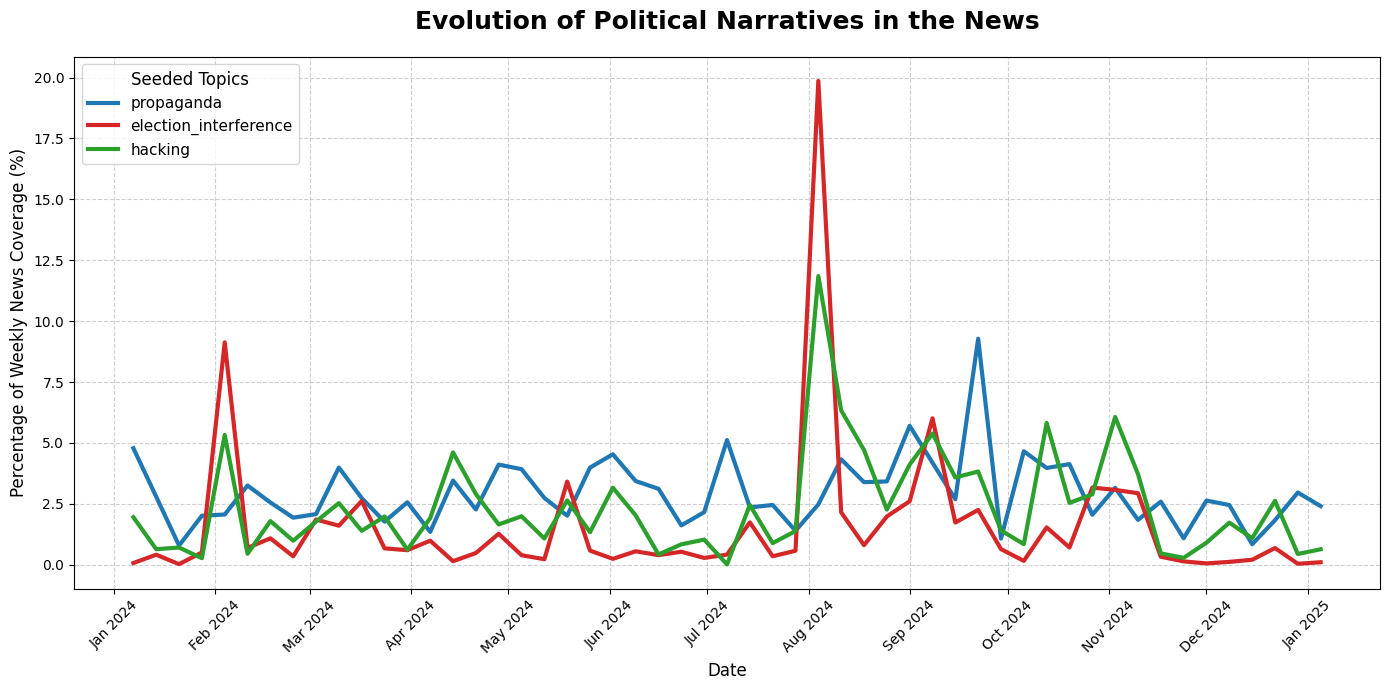

In [273]:


# ==========================================
# 1. EXTRACT DATA & REASSEMBLE THE CHUNKS
# ==========================================
print("Extracting topic distributions...")

# Create a list to hold the data for every chunk
chunk_data = []

# Loop through every document in the tomotopy model
for idx, doc in enumerate(mdl.docs):
    # Get the mathematical distribution across all topics for this specific chunk
    dist = doc.get_topic_dist()
    
    # Get the original article index from our chunked dataframe
    original_idx = df_chunked.iloc[idx]['Original_Index']
    
    # Store it as a dictionary
    row_data = {'Original_Index': original_idx}
    for k_id, prob in enumerate(dist):
        row_data[f'Topic_{k_id}'] = prob
        
    chunk_data.append(row_data)

# Convert to a DataFrame
df_dists = pd.DataFrame(chunk_data)

# Because one article was split into multiple chunks, we group by the Original_Index
# and take the mean to reconstruct the article's total topic distribution.
df_article_topics = df_dists.groupby('Original_Index').mean().reset_index()

# ==========================================
# 2. MERGE WITH THE ORIGINAL TIMESTAMPS
# ==========================================
# Merge the topic distributions back into your original dataframe using the index
# (Assuming your original dataframe has a column named 'Published_Date')
df_final = df_w_texts[['Event_Date']].merge(
    df_article_topics, 
    left_index=True, 
    right_on='Original_Index'
)

# Ensure the date column is officially recognized by pandas as a Datetime object
df_final['Published_Date'] = pd.to_datetime(
    df_final['Event_Date'].astype(str), 
    format='%Y%m%d'
)

# ==========================================
# 3. AGGREGATE BY WEEK & SMOOTH
# ==========================================
# Set the date as the index so we can do time-series math
df_final.set_index('Published_Date', inplace=True)

# Group the data by Week ('W') and calculate the mean topic probability for that week
weekly_trends = df_final.resample('W').mean()

# Apply a 3-week rolling average to smooth out the jagged spikes
# min_periods=1 ensures the graph doesn't drop the first two weeks
smoothed_trends = weekly_trends.rolling(window=1, min_periods=1).mean()

# ==========================================
# 4. PLOTTING THE EVOLUTION
# ==========================================
# Set up a large, clean figure
plt.figure(figsize=(14, 7))

# Choose which specific topics you want to plot so it isn't too cluttered
# Let's assume you want to plot your seeded topics (e.g., IDs 0, 1, and 2)
# You can look up your exact IDs from your `topic_id_to_name` mapping
topics_to_plot = [0, 1, 2] 

# Define some nice colors
colors = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd']

for i, k_id in enumerate(topics_to_plot):
    # Get the human-readable label
    label = topic_id_to_name.get(k_id, f"Topic {k_id}")
    
    # Plot the smoothed line
    # Multiply by 100 to convert decimals to percentages (e.g., 0.25 -> 25%)
    plt.plot(
        smoothed_trends.index, 
        smoothed_trends[f'Topic_{k_id}'] * 100, 
        label=label, 
        linewidth=3,
        color=colors[i % len(colors)]
    )

# Format the Graph visually
plt.title("Evolution of Political Narratives in the News", fontsize=18, fontweight='bold', pad=20)
plt.ylabel("Percentage of Weekly News Coverage (%)", fontsize=12)
plt.xlabel("Date", fontsize=12)

# Format the X-axis dates nicely
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=1)) # Show a tick every 1 month
plt.xticks(rotation=45)

# Add a grid, legend, and layout
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Seeded Topics", fontsize=11, title_fontsize=12, loc='upper left')
plt.tight_layout()

# Save or display the plot
plt.savefig("topic_evolution.png", dpi=300)
plt.show()

### BERTopic Modelling ???

### Tritopic

In [ ]:
from tritopic import TriTopic

In [156]:
documents =  [" ".join(sublist) for sublist in final_chunked_documents]  # df_w_texts["Full_Text"].tolist()

In [157]:
model_tri = TriTopic(verbose = True)
model_tri.config.embedding_batch_size = 64
model_tri.config.n_neighbors = 30
model_tri.config.n_topics = "auto"
model_tri.config.keyword_methods = "bm25"
model_tri.config.reduced_dims = 10
model_tri.config.embedding_model = "all-mpnet-base-v2"

In [158]:
labels = model_tri.fit_transform(documents)

[TriTopic] Fitting model on 948 documents
   Config: hybrid graph, iterative mode
   > Generating embeddings (all-mpnet-base-v2)...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 23999.41it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]
c:\Users\danie\anaconda3\envs\interference\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


   > Reducing dimensions to 10d (umap)...
   > Building lexical similarity matrix...
   > Starting iterative refinement (max 5 iterations)...
      Iteration 1...
      Iteration 2...
         ARI vs previous: 0.9135
      Iteration 3...
         ARI vs previous: 0.9409
      Iteration 4...
         ARI vs previous: 0.9759
      Converged at iteration 4
   > Extracting keywords and representative documents...

[OK] Fitting complete!
   Found 25 topics
   0 outlier documents (0.0%)


In [159]:
documents[4]

'united_states presidential_election week microsoft russia_iran china diverse array influence_operation trump_harris ballot_race area policy president approach ai expert second_trump presidency dangerous implication safety transparency fairness ai platform wired deep dive bitcoin recovery fanatic zachxbt billion_dollar cryptocurrency big cryptocurrency theft single victim saga nigeria money_laundering tax evasion charge binance executive irs agent tigran gambaryan united_nations women database sensitive file accessible organization vulnerable population world wired anti kremlin_propaganda group north_atlantic fella organization million_dollar supply ukrainian_soldier russia department_homeland security local agency warning economic risk chinese utility storage battery expense secure battery supply_chain document national_security transparency nonprofit property wired immigration customs enforcement contract surveillance vendor paragon solutions scrutiny white_house potential noncomplia

In [160]:
print(model_tri.get_topic_info())

    Topic  Size                                           Keywords  \
0       2    71                   tiktok, app, bytedance, ban, vpn   
1       9    71  rt, kremlin, justice_department, indictment, i...   
2      11    70           raddatz, harris, trump, comer, moskowitz   
3      13    65      china, chinese, falun_gong, beijing, shen_yun   
4      17    64          iran, iranian, tehran, regime, pezeshkian   
5       7    60            musk, putin, greene, yeshitela, johnson   
6       5    58              ukraine, nato, ukrainian, eu, russian   
7       8    56                   si, soviet, cpsu, putin, russian   
8      21    49                  israel, hamas, israeli, gaza, idf   
9      15    47              taiwan, republic, prc, lai, taiwanese   
10     18    44  newsguard, alethea, censorship, clinton, disin...   
11     14    37  carlson, putin, tucker_carlson, gustaf_kilande...   
12     12    32             india, pakistan, indian, kashmir, modi   
13      6    30  ira

In [165]:
model_tri.get_topic(18).keywords

['newsguard',
 'alethea',
 'censorship',
 'clinton',
 'disinformation',
 'jankowicz',
 'twitter',
 'gec',
 'kerry',
 'zatko']

In [162]:
print(model_tri.get_document_topics(4))

[(6, 0.06519416544070616), (2, 0.06464915006116712), (18, 0.05666376878628728)]


In [93]:
print(model_tri.probabilities_[0])

[0.04321373 0.42221171 0.01782572 0.05723186 0.02338924 0.03738957
 0.01732366 0.0292186  0.05237942 0.0224968  0.01264063 0.01389059
 0.01578273 0.03190248 0.01702678 0.0147653  0.02525577 0.02613544
 0.01164717 0.02058216 0.01442108 0.0230423  0.02721804 0.01081007
 0.01219916]
